C:\Users\DELL\anaconda3\envs\classification\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\anaconda3\envs\classification\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\anaconda3\envs\classification\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


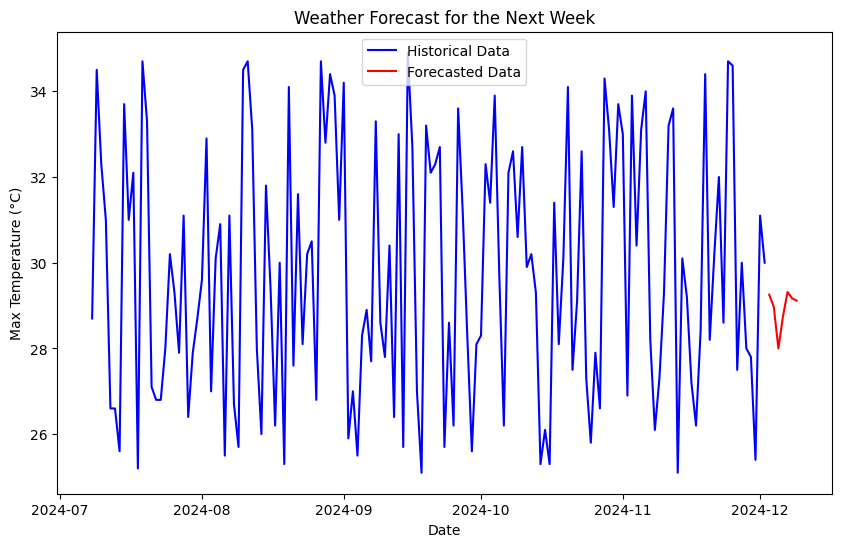

            Forecasted Temp (°C)
Date                            
2024-12-03             29.253850
2024-12-04             28.970005
2024-12-05             27.998912
2024-12-06             28.746625
2024-12-07             29.315790
2024-12-08             29.169442
2024-12-09             29.113564


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from datetime import timedelta

# Load your training data (Ensure Date column is in datetime format)
train = pd.read_csv('train_data.csv', parse_dates=['Date'], index_col='Date')

# Fit the ARIMA model (choose appropriate p, d, q)
# Example: ARIMA(5, 1, 0), you can tune these parameters later
model = ARIMA(train['Max Temp (°C)'], order=(5, 1, 0))
model_fit = model.fit()

# Forecast the next 7 days (next week)
forecast_steps = 7
forecast = model_fit.forecast(steps=forecast_steps)

# Create a DataFrame with forecasted values and corresponding dates
forecast_dates = [train.index[-1] + timedelta(days=i) for i in range(1, forecast_steps + 1)]
forecast_df = pd.DataFrame({'Date': forecast_dates, 'Forecasted Temp (°C)': forecast})
forecast_df.set_index('Date', inplace=True)

# Plot the historical data along with the forecast
plt.figure(figsize=(10, 6))
plt.plot(train.index, train['Max Temp (°C)'], label='Historical Data', color='blue')
plt.plot(forecast_df.index, forecast_df['Forecasted Temp (°C)'], label='Forecasted Data', color='red')
plt.title('Weather Forecast for the Next Week')
plt.xlabel('Date')
plt.ylabel('Max Temperature (°C)')
plt.legend()
plt.show()

# Print the forecasted temperatures
print(forecast_df)


C:\Users\DELL\anaconda3\envs\classification\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\anaconda3\envs\classification\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\anaconda3\envs\classification\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


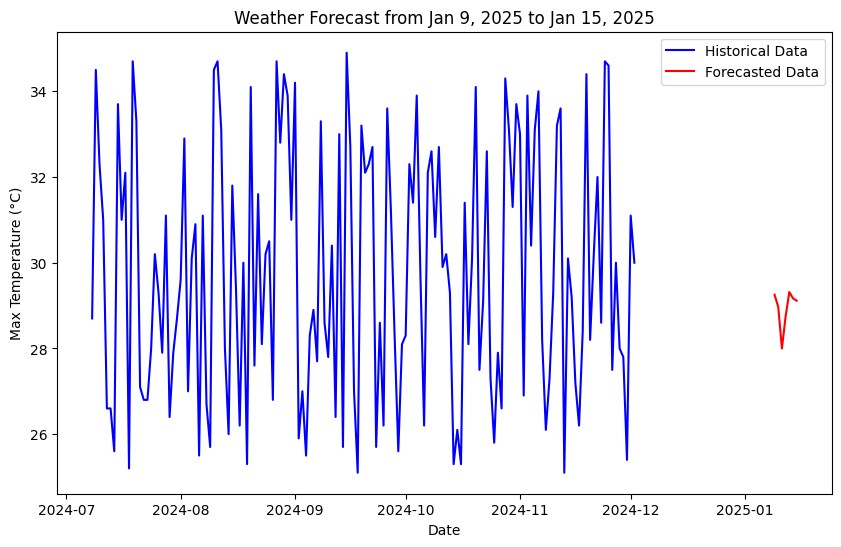

            Forecasted Temp (°C)
Date                            
2025-01-09             29.253850
2025-01-10             28.970005
2025-01-11             27.998912
2025-01-12             28.746625
2025-01-13             29.315790
2025-01-14             29.169442
2025-01-15             29.113564


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from datetime import timedelta

# Load your training data (ensure Date column is in datetime format)
train = pd.read_csv('train_data.csv', parse_dates=['Date'], index_col='Date')

# Fit the ARIMA model (choose appropriate p, d, q)
model = ARIMA(train['Max Temp (°C)'], order=(5, 1, 0))  # Adjust order as needed
model_fit = model.fit()

# Forecast the next 7 days (January 9th to 15th, 2025)
forecast_steps = 7
forecast = model_fit.forecast(steps=forecast_steps)

# Create a DataFrame with forecasted values and corresponding dates
forecast_dates = pd.date_range(start='2025-01-09', periods=forecast_steps, freq='D')
forecast_df = pd.DataFrame({'Date': forecast_dates, 'Forecasted Temp (°C)': forecast})
forecast_df.set_index('Date', inplace=True)

# Plot the historical data along with the forecast
plt.figure(figsize=(10, 6))
plt.plot(train.index, train['Max Temp (°C)'], label='Historical Data', color='blue')
plt.plot(forecast_df.index, forecast_df['Forecasted Temp (°C)'], label='Forecasted Data', color='red')
plt.title('Weather Forecast from Jan 9, 2025 to Jan 15, 2025')
plt.xlabel('Date')
plt.ylabel('Max Temperature (°C)')
plt.legend()
plt.show()

# Print the forecasted temperatures
print(forecast_df)


In [3]:
# Save the forecasted DataFrame to a CSV file
forecast_df.to_csv('forecast_data.csv')

print("Forecast data saved as 'forecast_data.csv'")


Forecast data saved as 'forecast_data.csv'


## Sarima model

C:\Users\DELL\anaconda3\envs\classification\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\anaconda3\envs\classification\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


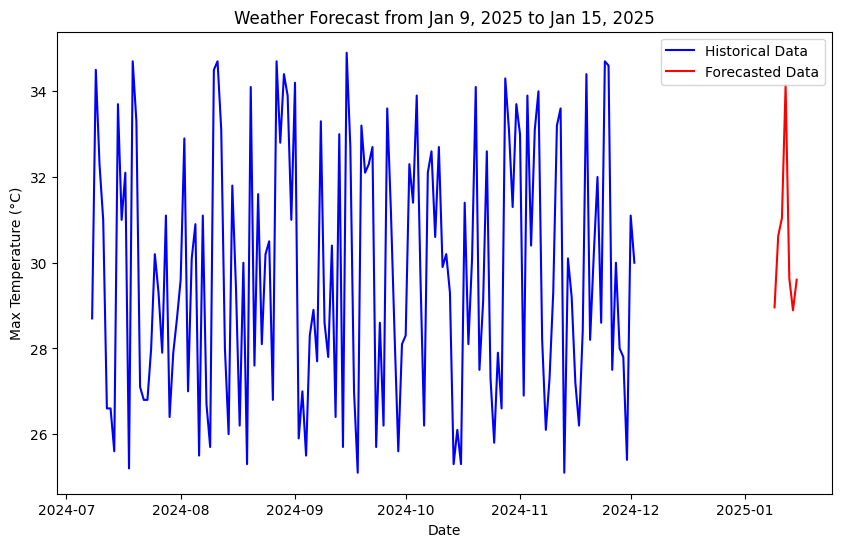

            Forecasted Temp (°C)
Date                            
2025-01-09             28.958242
2025-01-10             30.629252
2025-01-11             31.040079
2025-01-12             34.146335
2025-01-13             29.637083
2025-01-14             28.888252
2025-01-15             29.603620


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from datetime import timedelta

# Load your training data (ensure Date column is in datetime format)
train = pd.read_csv('train_data.csv', parse_dates=['Date'], index_col='Date')

# Fit the SARIMA model (choose appropriate p, d, q, P, D, Q, and m)
# m = 12 if seasonality is yearly; adjust based on the nature of your data
model = SARIMAX(train['Max Temp (°C)'], order=(1, 1, 1), seasonal_order=(1, 1, 0, 12))
model_fit = model.fit(disp=False)

# Forecast the next 7 days (January 9th to 15th, 2025)
forecast_steps = 7
forecast = model_fit.forecast(steps=forecast_steps)

# Create a DataFrame with forecasted values and corresponding dates
forecast_dates = pd.date_range(start='2025-01-09', periods=forecast_steps, freq='D')
forecast_df = pd.DataFrame({'Date': forecast_dates, 'Forecasted Temp (°C)': forecast})
forecast_df.set_index('Date', inplace=True)

# Plot the historical data along with the forecast
plt.figure(figsize=(10, 6))
plt.plot(train.index, train['Max Temp (°C)'], label='Historical Data', color='blue')
plt.plot(forecast_df.index, forecast_df['Forecasted Temp (°C)'], label='Forecasted Data', color='red')
plt.title('Weather Forecast from Jan 9, 2025 to Jan 15, 2025')
plt.xlabel('Date')
plt.ylabel('Max Temperature (°C)')
plt.legend()
plt.show()

# Print the forecasted temperatures
print(forecast_df)




## Holt-Winters Exponential Smoothing

C:\Users\DELL\anaconda3\envs\classification\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


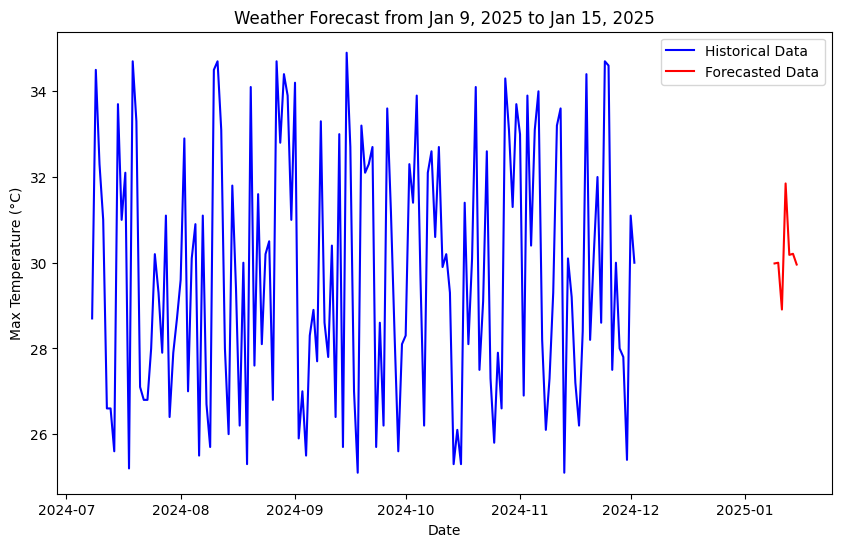

            Forecasted Temp (°C)
Date                            
2025-01-09             29.982993
2025-01-10             29.999666
2025-01-11             28.907990
2025-01-12             31.849658
2025-01-13             30.183000
2025-01-14             30.207998
2025-01-15             29.957998


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Load your training data (ensure Date column is in datetime format)
train = pd.read_csv('train_data.csv', parse_dates=['Date'], index_col='Date')

# Fit the Holt-Winters Exponential Smoothing model
# Use seasonal='add' or seasonal='mul' depending on your data characteristics
model = ExponentialSmoothing(
    train['Max Temp (°C)'], 
    trend='add',            # Additive trend
    seasonal='add',         # Additive seasonality
    seasonal_periods=12     # Adjust based on seasonality (e.g., 12 for yearly seasonality in monthly data)
)
model_fit = model.fit()

# Forecast the next 7 days (January 9th to 15th, 2025)
forecast_steps = 7
forecast = model_fit.forecast(steps=forecast_steps)

# Create a DataFrame with forecasted values and corresponding dates
forecast_dates = pd.date_range(start='2025-01-09', periods=forecast_steps, freq='D')
forecast_df = pd.DataFrame({'Date': forecast_dates, 'Forecasted Temp (°C)': forecast})
forecast_df.set_index('Date', inplace=True)

# Plot the historical data along with the forecast
plt.figure(figsize=(10, 6))
plt.plot(train.index, train['Max Temp (°C)'], label='Historical Data', color='blue')
plt.plot(forecast_df.index, forecast_df['Forecasted Temp (°C)'], label='Forecasted Data', color='red')
plt.title('Weather Forecast from Jan 9, 2025 to Jan 15, 2025')
plt.xlabel('Date')
plt.ylabel('Max Temperature (°C)')
plt.legend()
plt.show()

# Print the forecasted temperatures
print(forecast_df)




In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Load your training data (ensure Date column is in datetime format)
train = pd.read_csv('train_data.csv', parse_dates=['Date'], index_col='Date')

# Define the forecast steps (January 9th to 15th, 2025)
forecast_steps = 7
forecast_dates = pd.date_range(start='2025-01-09', periods=forecast_steps, freq='D')

# ================== ARIMA ================== #
arima_model = ARIMA(train['Max Temp (°C)'], order=(5, 1, 0))  # Adjust order as needed
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(steps=forecast_steps)

# ================== SARIMA ================== #
sarima_model = SARIMAX(train['Max Temp (°C)'], order=(1, 1, 1), seasonal_order=(1, 1, 0, 12))
sarima_fit = sarima_model.fit(disp=False)
sarima_forecast = sarima_fit.forecast(steps=forecast_steps)

# ================== Holt-Winters ================== #
holt_winters_model = ExponentialSmoothing(
    train['Max Temp (°C)'], 
    trend='add', 
    seasonal='add', 
    seasonal_periods=12  # Adjust based on seasonality
)
holt_winters_fit = holt_winters_model.fit()
holt_winters_forecast = holt_winters_fit.forecast(steps=forecast_steps)

# Create a DataFrame for all forecasts
forecast_df = pd.DataFrame({
    'Date': forecast_dates,
    'ARIMA Forecast (°C)': arima_forecast,
    'SARIMA Forecast (°C)': sarima_forecast,
    'Holt-Winters Forecast (°C)': holt_winters_forecast
})
forecast_df.set_index('Date', inplace=True)

# ================== Plotting ================== #
plt.figure(figsize=(12, 8))

# Plot historical data
plt.plot(train.index, train['Max Temp (°C)'], label='Historical Data', color='blue')

# Plot forecasts from all models
plt.plot(forecast_df.index, forecast_df['ARIMA Forecast (°C)'], label='ARIMA Forecast', color='red')
plt.plot(forecast_df.index, forecast_df['SARIMA Forecast (°C)'], label='SARIMA Forecast', color='green')
plt.plot(forecast_df.index, forecast_df['Holt-Winters Forecast (°C)'], label='Holt-Winters Forecast', color='orange')

# Customize plot
plt.title('Weather Forecast Comparison (Jan 9 - Jan 15, 2025)')
plt.xlabel('Date')
plt.ylabel('Max Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()


# Print combined forecasts
print(forecast_df) 